# ASELSAN Stock Prices
ASELSAN is the largest defense electronics company of Turkey whose capability/product portfolio comprises communication and information technologies, radar and electronic warfare, electro-optics, avionics, unmanned systems, land, naval and weapon systems, air defence and missile systems, command and control systems, transportation, security, traffic, automation and medical systems. Today ASELSAN has become an indigenous products exporting company, investing in international markets through various cooperation models with local partners and listed as one of the top 100 defence companies of the world. This dataset contains stock prices of ASELSAN from 2017 to 2022. This dataset is designed for stock price prediction, and financial analysis. Therefore, this dataset is offered for testing prediction models and algos, financial analysis applications and so on

Aim of the project to create a ML model which will predict the stock prices.

# DataSet
I have Downloaded this dataset from kaggle website. Here is the link:https://www.kaggle.com/datasets/zlemglsmklkaya/aselsan-stock-prices-20172022

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn


In [52]:
import warnings
warnings.filterwarnings('ignore')

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [54]:
from sklearn.linear_model import  LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor

In [55]:
df=pd.read_csv("/content/ASELSAN-2017-2022.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-06-15,11.00,11.06,10.92,11.03,10.695765,7122628
1,2017-06-16,11.03,11.08,10.92,10.92,10.589099,7462226
2,2017-06-19,10.95,10.97,10.90,10.90,10.569703,4526662
3,2017-06-20,10.92,10.97,10.84,10.85,10.521218,4386578
4,2017-06-21,10.86,11.04,10.77,10.99,10.656976,9809562


In [56]:
df.index =df.Date
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2017-06-15,2017-06-15,11.00,11.06,10.92,11.03,10.695765,7122628
2017-06-16,2017-06-16,11.03,11.08,10.92,10.92,10.589099,7462226
2017-06-19,2017-06-19,10.95,10.97,10.90,10.90,10.569703,4526662
2017-06-20,2017-06-20,10.92,10.97,10.84,10.85,10.521218,4386578
2017-06-21,2017-06-21,10.86,11.04,10.77,10.99,10.656976,9809562


In [57]:
df.drop("Date",axis=1,inplace=True)

In [58]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-06-15,11.00,11.06,10.92,11.03,10.695765,7122628
2017-06-16,11.03,11.08,10.92,10.92,10.589099,7462226
2017-06-19,10.95,10.97,10.90,10.90,10.569703,4526662
2017-06-20,10.92,10.97,10.84,10.85,10.521218,4386578
2017-06-21,10.86,11.04,10.77,10.99,10.656976,9809562


In [59]:
print(f"Maximum Date: {df.index.max()}")
print(f"Minimum Date: {df.index.min()}")

Maximum Date: 2022-06-14
Minimum Date: 2017-06-15


In [60]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-06-15,11.00,11.06,10.92,11.03,10.695765,7122628
2017-06-16,11.03,11.08,10.92,10.92,10.589099,7462226
2017-06-19,10.95,10.97,10.90,10.90,10.569703,4526662
2017-06-20,10.92,10.97,10.84,10.85,10.521218,4386578
2017-06-21,10.86,11.04,10.77,10.99,10.656976,9809562


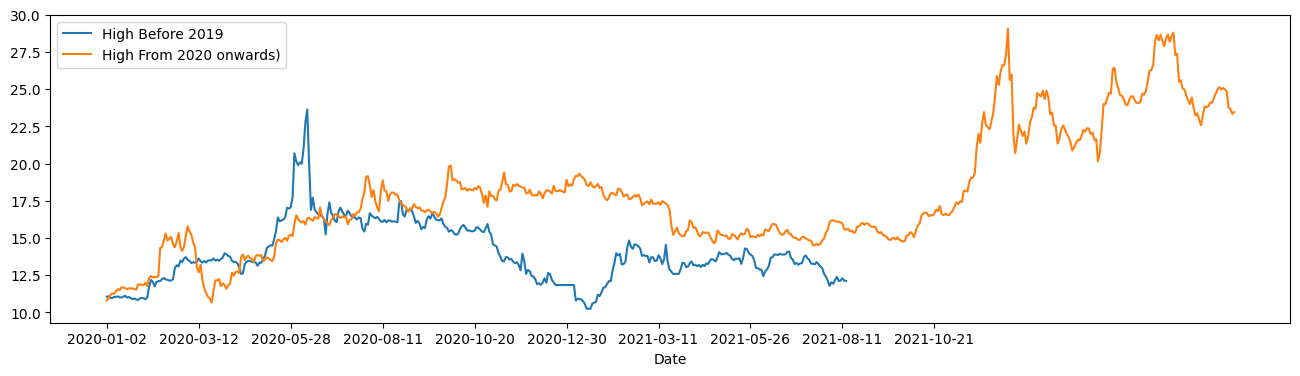

In [61]:
df["High"][:'2019'].plot(figsize=(16,4),legend=True)
df["High"]['2020':].plot(figsize=(16,4),legend=True)
plt.legend(['High Before 2019','High From 2020 onwards)'])

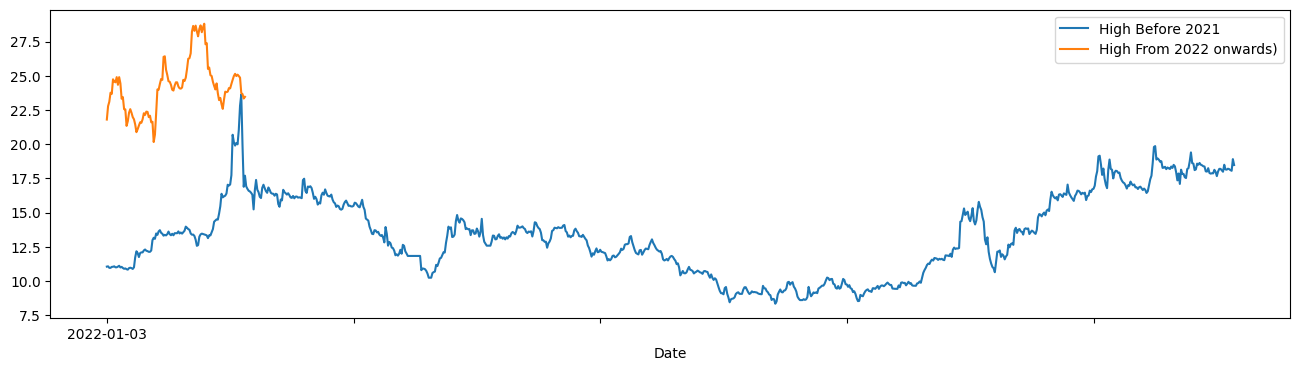

In [62]:
df["High"][:'2021'].plot(figsize=(16,4),legend=True)
df["High"]['2022':].plot(figsize=(16,4),legend=True)
plt.legend(['High Before 2021','High From 2022 onwards)'])

Creating the Model and Prediction of Price


In [63]:
y,x=df.High,df.drop("High",axis=1)

y = target (what we want to predict → High price)

x = features (all other columns)

In [64]:
ytrain=np.array(y[:'2019'])
ytest=np.array(y["2020":])
xtrain=np.array(x[:"2019"])
xtest=np.array(x["2020":])

In [65]:
def plot_model(test,pred):
    plt.plot(test, color='red',label='ASELSAN Stock Price')
    plt.plot(pred, color='blue',label='pred ASELSAN stock Price')
    plt.title('ASELSAN Prediction')
    plt.xlabel('Time')
    plt.ylabel('cfars')
    plt.legend()
    plt.show()

In [66]:
lr=LinearRegression()
lr.fit(xtrain,ytrain)
ypred_lr=lr.predict(xtest)

ridge=Ridge(alpha=5)
ridge.fit(xtrain,ytrain)
ypred_ridge=ridge.predict(xtest)

lasso=Lasso(alpha=5)
lasso.fit(xtrain,ytrain)
ypred_lasso=ridge.predict(xtest)

dtr=DecisionTreeRegressor(criterion='squared_error', splitter='best', max_depth=7)
dtr.fit(xtrain,ytrain)
ypred_dtr=dtr.predict(xtest)

In [67]:
list_model=[lr,ridge,lasso,dtr]
for model in list_model:
    score_train=model.score(xtrain,ytrain)
    score_test=model.score(xtest,ytest)
    print("score train is ",score_train,"score test is ",score_test)

score train is  0.9948911508028093 score test is  0.98129653435915
score train is  0.9940796612257581 score test is  0.9949617507373402
score train is  0.012687986067629553 score test is  -0.8632125275634959
score train is  0.9991942550065751 score test is  0.8605745230426619


#linear Regression model (lr)

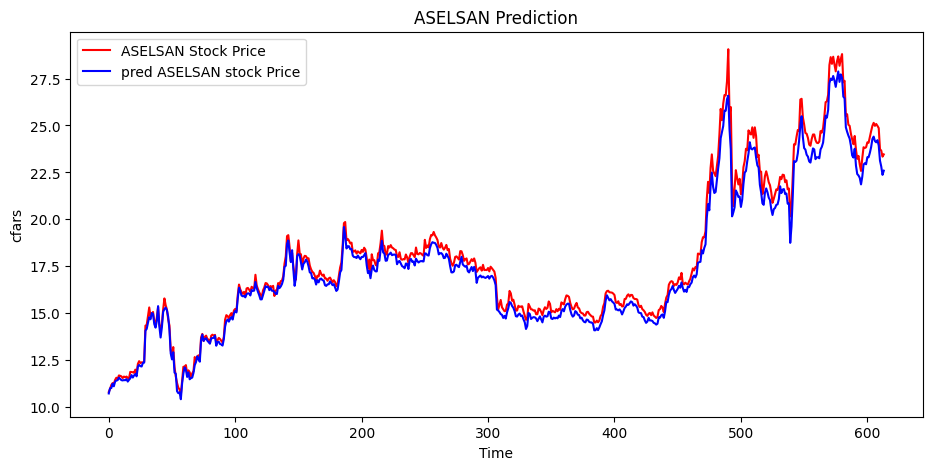

In [68]:
plt.figure(figsize=(11,5))
plot_model(ytest.reshape(-1,1),ypred_lr.reshape(-1,1))

#Ridge model

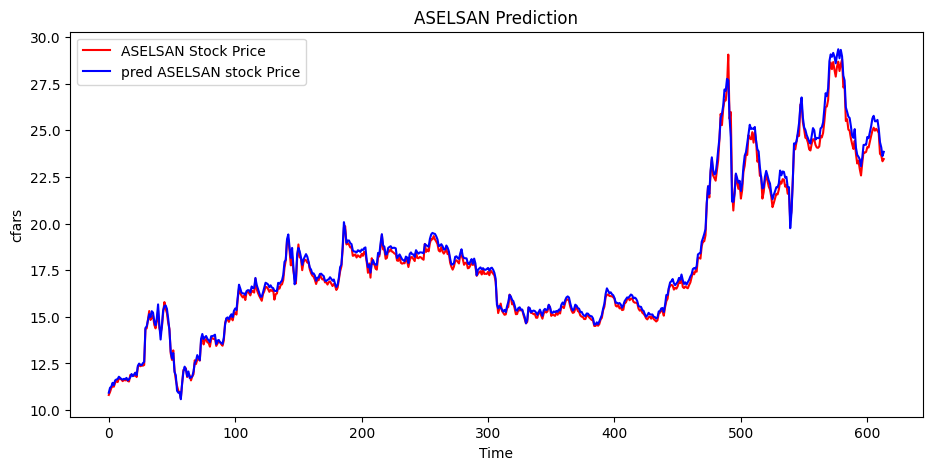

In [69]:
plt.figure(figsize=(11,5))
plot_model(ytest.reshape(-1,1),ypred_ridge.reshape(-1,1))

#lesso model

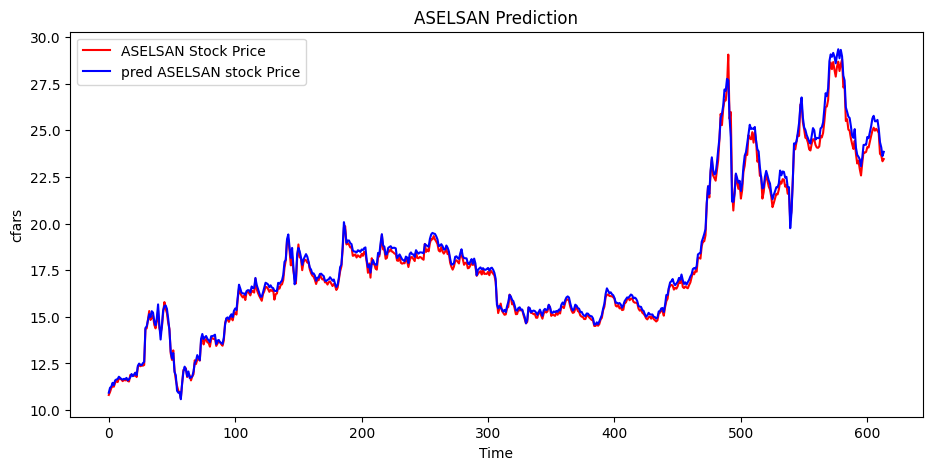

In [70]:
plt.figure(figsize=(11,5))
plot_model(ytest.reshape(-1,1),ypred_lasso.reshape(-1,1))

#Descision tree model

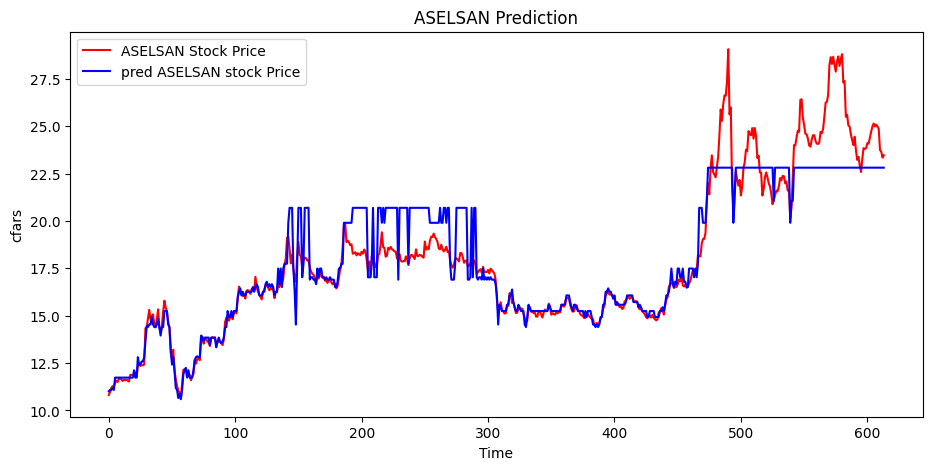

In [71]:
plt.figure(figsize=(11,5))
plot_model(ytest.reshape(-1,1),ypred_dtr.reshape(-1,1))

# Conclusion all model
So basically, after training and testing all the models, this is what I observed:

1. Linear Regression performed quite well. It had a high training score and also a good test score, which means the model was able to learn the pattern properly and also worked fine on new data. So, it’s a good baseline model.

2. Ridge Regression gave the best overall performance. Both training and testing scores were very high and close to each other. This means it handled overfitting really well and generalized better than other models. So, this turned out to be the best model for this dataset.

3. Lasso Regression performed very poorly. The training score was very low and the test score was even negative, which means it was worse than just predicting the average value. This likely happened because the alpha value was too high, so the model removed too many important features and ended up underfitting.

3. Decision Tree Regressor had a very high training score, almost perfect, but the test score dropped a lot. This clearly shows overfitting — the model memorized the training data but couldn’t perform well on new data.

In [72]:
import pickle

# Save the Linear Regression model
with open('linear_regression_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

# Save the Ridge Regression model
with open('ridge_model.pkl', 'wb') as f:
    pickle.dump(ridge, f)

# Save the Lasso Regression model
with open('lasso_model.pkl', 'wb') as f:
    pickle.dump(lasso, f)

# Save the Decision Tree Regressor model
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump(dtr, f)

print("All models saved successfully!")

All models saved successfully!
